# CAPTCHA Experiment Result Visualization

This notebook provides two modes for visualizing experiment results:

## Mode A: Quick Generation (Recommended for first-time use)
- Run **Cell 1** only
- Automatically generates all charts and saves to `./figures/`

## Mode B: Custom Control (Recommended for fine-tuning)
- Run **Cell 2** first (imports and data loading)
- Then run any of **Cells 3-7** individually to generate specific charts
- Allows customization of parameters and selective plotting

---
# Mode A: Quick Generation
Run this cell to automatically generate all charts.

In [ ]:
# ============================================================================
# Mode A: Quick Generation - Generate All Charts Automatically
# ============================================================================

from visualize_results import quick_visualize
import matplotlib.pyplot as plt

print("=" * 80)
print("Mode A: Quick Chart Generation")
print("=" * 80)

# Quickly generate all charts
viz = quick_visualize(
    results_dir="./results",
    output_dir="./figures",
    show=False  # Set to True if you want to display charts in notebook
)

print("\n[COMPLETED] All charts saved to ./figures/ directory")
print("\nIf you need more control, use Mode B (Cells 2-7 below)")

---
# Mode B: Custom Control
Run Cell 2 first to import and load data, then run any of Cells 3-7 for specific charts.

In [2]:
# ============================================================================
# Mode B: Step 1 - Import Libraries and Load Data
# ============================================================================

from visualize_results import CAPTCHAVisualizer
import matplotlib.pyplot as plt
import pandas as pd

print("=" * 80)
print("Mode B: Custom Chart Control")
print("=" * 80)

# Initialize visualizer
viz = CAPTCHAVisualizer(results_dir="./results")

# View loaded data summary
print("\nData Summary:")
print(f"- Total records: {len(viz.data)}")
print(f"- Task types: {len(viz.task_types)}")
if not viz.data.empty:
    print(f"- Experiments: {sorted(viz.data['experiment'].unique())}")
    print(f"- Models: {sorted(viz.data['provider_model'].unique())}")
else:
    print("[WARNING] No data found")

print("\n[READY] You can now run Cells 3-7 to generate specific charts")

Mode B: Custom Chart Control
Scanning experiment result directories...
[LOADED] exp1/gemini/gemini-2.5-flash (18 records)
[LOADED] exp1/fireworks/accounts_fireworks_models_qwen3-vl-235b-a22b-instruct (18 records)
[LOADED] exp1/anthropic/claude-sonnet-4-5 (1 records)
[LOADED] exp1/openai/gpt-5 (18 records)
[LOADED] exp1/openai/gpt-5-chat-latest (18 records)
[LOADED] exp3/gemini/gemini-2.5-flash (18 task types, converted from Exp3 format)
[LOADED] exp3/fireworks/accounts_fireworks_models_qwen3-vl-235b-a22b-instruct (18 task types, converted from Exp3 format)
[LOADED] exp3/openai/gpt-5 (18 task types, converted from Exp3 format)
[LOADED] exp3/openai/gpt-5-chat-latest (18 task types, converted from Exp3 format)
[LOADED] exp4/gemini/gemini-2.5-flash (4 records)
[LOADED] exp4/openai/gpt4o (1 records)
[LOADED] exp4/openai/gpt-5 (4 records)
[LOADED] exp4/openai/gpt-5-chat-latest (4 records)
[LOADED] exp2/gemini/gemini-2.5-flash (18 records)
[LOADED] exp2/fireworks/accounts_fireworks_models_qwe

## Chart 1: Heatmap - Task Difficulty Overview
Displays all task types' performance across different models.


Generating heatmap (Exp1 Baseline)...


FileNotFoundError: [Errno 2] No such file or directory: './figures/heatmap_exp1.png'

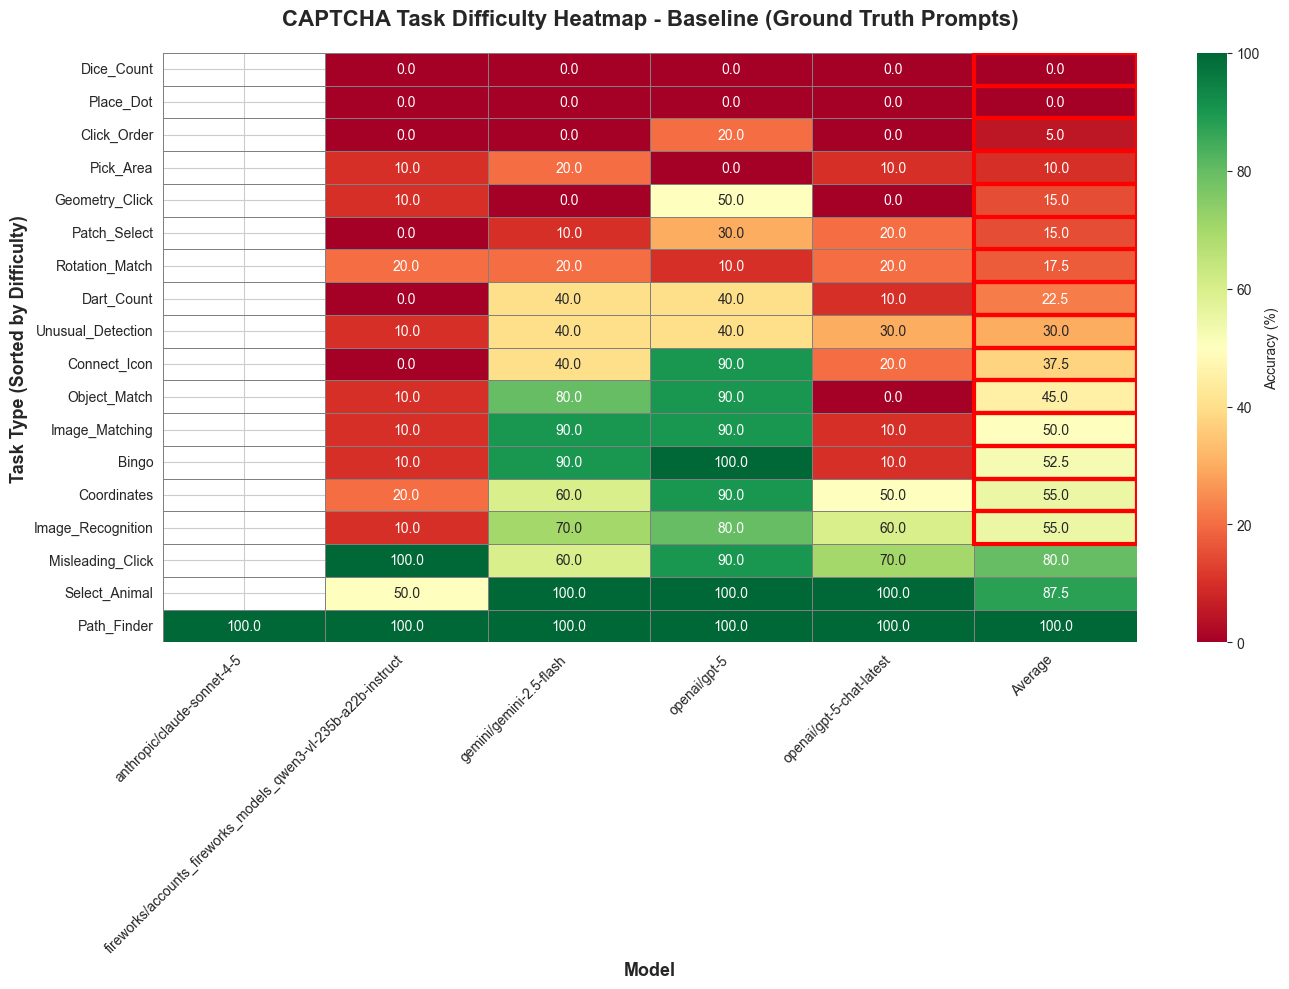

In [3]:
# Chart 1: Heatmap - Task Difficulty Overview

if not viz.data.empty and 'exp1' in viz.data['experiment'].values:
    print("\nGenerating heatmap (Exp1 Baseline)...")
    fig = viz.plot_heatmap(
        experiment='exp1',
        figsize=(14, 10),
        save_path="./figures/heatmap_exp1.pdf"
    )
    plt.show()
else:
    print("[WARNING] Insufficient Exp1 data, skipping heatmap")

## Chart 2: Grouped Bar Chart - Optimization Effect Comparison
Compares accuracy changes across different experiments.

In [ ]:
# Chart 2: Grouped Bar Chart - Optimization Effect Comparison

if not viz.data.empty:
    available_exps = sorted(viz.data['experiment'].unique())
    if len(available_exps) >= 2:
        print("\nGenerating optimization comparison bar chart...")
        fig = viz.plot_comparison_bars(
            experiments=available_exps,
            model_filter="openai/gpt-5-chat-latest",  # Change to your target model
            figsize=(18, 7),
            save_path="./figures/comparison_bars.pdf"
        )
        plt.show()
    else:
        print("[WARNING] Less than 2 experiments, skipping bar chart")
else:
    print("[WARNING] No data")

## Chart 3: Scatter Plot - Optimization Resistance Analysis
Identifies which task types remain difficult even after optimization.

In [ ]:
# Chart 3: Scatter Plot - Optimization Resistance Analysis

if not viz.data.empty and 'exp1' in viz.data['experiment'].values and 'exp2' in viz.data['experiment'].values:
    print("\nGenerating optimization resistance scatter plot...")
    fig = viz.plot_optimization_resistance(
        base_exp='exp1',
        opt_exp='exp2',
        model_filter="openai/gpt-5-chat-latest",  # Change to your target model
        figsize=(11, 11),
        save_path="./figures/optimization_resistance.pdf"
    )
    plt.show()
else:
    print("[WARNING] Requires both Exp1 and Exp2 data, skipping scatter plot")

## Chart 4: Box Plot - Cross-Model Stability
Analyzes performance variance across different models.

In [ ]:
# Chart 4: Box Plot - Cross-Model Stability

if not viz.data.empty and 'exp1' in viz.data['experiment'].values:
    # Check if there are multiple models for comparison
    n_models = len(viz.data[viz.data['experiment'] == 'exp1']['provider_model'].unique())
    if n_models >= 2:
        print("\nGenerating cross-model stability box plot...")
        fig = viz.plot_cross_model_stability(
            experiment='exp1',
            figsize=(16, 8),
            save_path="./figures/stability_exp1.pdf"
        )
        plt.show()
    else:
        print(f"[WARNING] Only {n_models} model(s) found, need at least 2 for stability analysis")
else:
    print("[WARNING] Insufficient data for stability analysis")

## CAPTCHA Recommendation Report
Generates a detailed analysis report for CAPTCHA task selection.

In [ ]:
# ============================================================================
# CAPTCHA Recommendation Report
# ============================================================================

if not viz.data.empty and 'exp2' in viz.data['experiment'].values:
    print("\n" + "=" * 80)
    print("CAPTCHA Recommended Task Types Analysis (Based on Exp2 Optimized Results)")
    print("=" * 80)

    # Generate recommendation list
    recommendations = viz.generate_captcha_recommendation(
        experiment='exp2',
        threshold=60.0,
        top_n=10
    )

    print("\nTop 10 Recommended CAPTCHA Task Types:\n")
    print(recommendations.to_string())

    print("\n\nField Descriptions:")
    print("  - rank: Recommendation ranking")
    print("  - avg_accuracy: Average accuracy (%) - lower is harder")
    print("  - std_accuracy: Standard deviation (%) - lower means more stable across models")
    print("  - n_models: Number of models tested")
    print("  - captcha_score: Recommendation score (difficulty 60% + stability 40%)")

    # Save recommendation list
    recommendations.to_csv("./figures/captcha_recommendations.csv", index=True)
    print("\n[SAVED] Recommendation list saved to: ./figures/captcha_recommendations.csv")

    # Exp1 vs Exp2 Comparison
    if 'exp1' in viz.data['experiment'].values:
        print("\n" + "=" * 80)
        print("Exp1 (Baseline) vs Exp2 (Optimized) Effect Comparison")
        print("=" * 80)

        exp1_acc = viz.data[viz.data['experiment'] == 'exp1'].groupby('task_type')['pass'].mean() * 100
        exp2_acc = viz.data[viz.data['experiment'] == 'exp2'].groupby('task_type')['pass'].mean() * 100

        comparison = pd.DataFrame({
            'Exp1_Baseline': exp1_acc,
            'Exp2_Optimized': exp2_acc,
            'Improvement': exp2_acc - exp1_acc
        }).round(2)

        comparison = comparison.sort_values('Improvement', ascending=False)

        print("\nTask Types with Greatest Improvement (Top 5):")
        print(comparison.head(5).to_string())

        print("\nTask Types with Degradation:")
        negative = comparison[comparison['Improvement'] < 0]
        if not negative.empty:
            print(negative.to_string())
        else:
            print("  No degraded task types")

        print("\nOverall Statistics:")
        print(f"  - Improved task types: {len(comparison[comparison['Improvement'] > 0])}")
        print(f"  - Unchanged task types: {len(comparison[comparison['Improvement'] == 0])}")
        print(f"  - Degraded task types: {len(comparison[comparison['Improvement'] < 0])}")
        print(f"  - Average improvement: {comparison['Improvement'].mean():.2f}%")
else:
    print("[WARNING] Requires Exp2 data to generate recommendation report")

print("\n[COMPLETED] All analysis finished!")